In [1]:
import numpy as np
import matplotlib.pyplot as plt

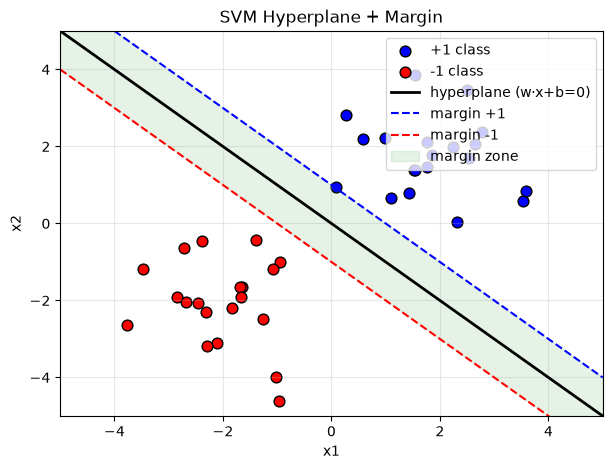

In [2]:
# Cell 2 — Version 1: what is a hyperplane?
# In 2D: w0*x1 + w1*x2 + b = 0  →  a line
# Points above → class +1, points below → class -1

# simple linearly separable data
np.random.seed(42)
X_pos = np.column_stack([np.random.randn(20)+2, np.random.randn(20)+2])
X_neg = np.column_stack([np.random.randn(20)-2, np.random.randn(20)-2])
X = np.vstack([X_pos, X_neg])
y = np.array([1]*20 + [-1]*20)

# manually define a separating hyperplane: x2 = -x1  → x1 + x2 = 0
w = np.array([1.0, 1.0])
b = 0.0

x1_range = np.linspace(-5, 5, 300)
x2_boundary = (-w[0]*x1_range - b) / w[1]
x2_upper    = (-w[0]*x1_range - b + 1) / w[1]   # +1 margin
x2_lower    = (-w[0]*x1_range - b - 1) / w[1]   # -1 margin

plt.figure(figsize=(7, 5))
plt.scatter(X_pos[:,0], X_pos[:,1], c='blue', s=60, label='+1 class', edgecolors='k')
plt.scatter(X_neg[:,0], X_neg[:,1], c='red',  s=60, label='-1 class', edgecolors='k')
plt.plot(x1_range, x2_boundary, 'k-',  linewidth=2, label='hyperplane (w·x+b=0)')
plt.plot(x1_range, x2_upper,    'b--', linewidth=1.5, label='margin +1')
plt.plot(x1_range, x2_lower,    'r--', linewidth=1.5, label='margin -1')
plt.fill_between(x1_range, x2_lower, x2_upper, alpha=0.1, color='green', label='margin zone')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('SVM Hyperplane + Margin')
plt.legend(loc='upper right'); plt.grid(True, alpha=0.3)
plt.xlim(-5, 5); plt.ylim(-5, 5); plt.show()

In [3]:
# Cell 3 — Version 2: margin width formula
# Margin width = 2 / ||w||
# Maximising margin = minimising ||w||

w1 = np.array([1.0, 1.0])
w2 = np.array([2.0, 2.0])
w3 = np.array([0.5, 0.5])

for w in [w1, w2, w3]:
    margin = 2 / np.linalg.norm(w)
    print(f"w={w}  ||w||={np.linalg.norm(w):.4f}  margin={margin:.4f}")

print("\nSmaller ||w|| → larger margin → better SVM ✅")
print("SVM training = minimise (1/2)||w||² subject to constraints")

w=[1. 1.]  ||w||=1.4142  margin=1.4142
w=[2. 2.]  ||w||=2.8284  margin=0.7071
w=[0.5 0.5]  ||w||=0.7071  margin=2.8284

Smaller ||w|| → larger margin → better SVM ✅
SVM training = minimise (1/2)||w||² subject to constraints


In [4]:
# Cell 4 — Version 3: functional margin — classify points
# For a point x: decision = sign(w·x + b)
# Functional margin = y * (w·x + b)  → positive means correct classification

w = np.array([1.0, 1.0])
b = 0.0

test_points = np.array([[3, 3], [-3, -3], [0.1, 0.1], [-0.1, -0.1]])
true_labels = np.array([1, -1, 1, -1])

print(f"{'Point':15s} {'True':6s} {'w·x+b':8s} {'Pred':6s} {'Correct?':10s} {'Margin':8s}")
print("-"*60)
for x, y_true in zip(test_points, true_labels):
    score = np.dot(w, x) + b
    pred  = np.sign(score)
    fm    = y_true * score
    print(f"{str(x):15s} {y_true:6.0f} {score:8.3f} {pred:6.0f} "
          f"{'✅' if pred==y_true else '❌':10s} {fm:8.3f}")

print("\nFunctional margin > 0 → correct side of boundary")
print("Functional margin > 1 → outside margin zone (confident)")

Point           True   w·x+b    Pred   Correct?   Margin  
------------------------------------------------------------
[3. 3.]              1    6.000      1 ✅             6.000
[-3. -3.]           -1   -6.000     -1 ✅             6.000
[0.1 0.1]            1    0.200      1 ✅             0.200
[-0.1 -0.1]         -1   -0.200     -1 ✅             0.200

Functional margin > 0 → correct side of boundary
Functional margin > 1 → outside margin zone (confident)


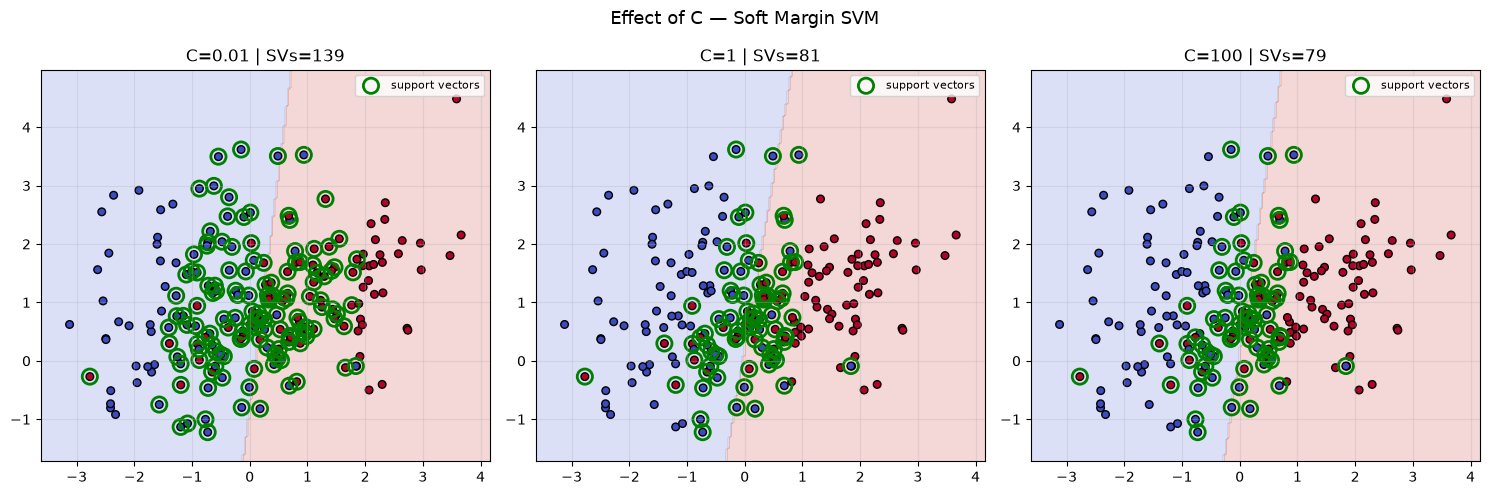

Large C → fewer support vectors, tighter margin
Small C → more support vectors, wider margin ✅


In [5]:
# Cell 5 — Version 4: effect of C parameter (soft margin intuition)
# Hard margin: no misclassification allowed (only works if linearly separable)
# Soft margin: allow some misclassification via slack variables ξ
# C = penalty for misclassification
# Large C → small margin, fewer errors (can overfit)
# Small C → large margin, more errors allowed (generalises better)

from sklearn.svm import SVC
from sklearn.datasets import make_classification

np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                            n_informative=2, random_state=42, n_clusters_per_class=1)
y = np.where(y == 0, -1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, C in zip(axes, [0.01, 1, 100]):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)

    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=30)
    ax.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
               s=120, facecolors='none', edgecolors='green', linewidths=2,
               label='support vectors')
    ax.set_title(f'C={C} | SVs={len(model.support_vectors_)}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Effect of C — Soft Margin SVM', fontsize=13)
plt.tight_layout(); plt.show()
print("Large C → fewer support vectors, tighter margin")
print("Small C → more support vectors, wider margin ✅")